In [1]:
from datetime import datetime, timedelta
from zoneinfo import ZoneInfo  # Available in Python 3.9+
import pytz
import os
import pandas as pd
import numpy as np
import logging
import time
import requests
from math import sqrt
import matplotlib.pyplot as plt
#import pandas as pd
#import numpy as np
import itertools #RJ_CODE moved the imports from
#from datetime import time

# Configure logging
logging.basicConfig(level=logging.INFO)
logger = logging.getLogger(__name__)

## Get Data

In [4]:
symbol = "QQQ"

csv3_filename = "QQQ_5min_Since_2016_v2_removingincomplete_days_2025-05-14.csv"
final_df_read = pd.read_csv(csv3_filename, parse_dates=['timestamp'])
final_df_read['timestamp'] = pd.to_datetime(final_df_read['timestamp'], utc=True, errors='coerce')
# Convert 'timestamp' from UTC to 'US/Eastern'
final_df_read['timestamp'] = final_df_read['timestamp'].dt.tz_convert('US/Eastern')

This transforms the data to fit the Conncretum Backtest code **Ignore**

In [6]:
"""
concretum_df=final_df_read.copy()
##DATA TO THEIR FORMAT
# Ensure timestamp is in datetime format and localized to Eastern Time
concretum_df['timestamp'] = pd.to_datetime(concretum_df['timestamp'])
concretum_df = concretum_df.set_index('timestamp')
if concretum_df.index.tz is None:
      concretum_df = concretum_df.tz_localize('US/Eastern')
else:
      concretum_df = concretum_df.tz_convert('US/Eastern')

# Sort by timestamp
concretum_df = concretum_df.sort_index()

#STRATEGY
# Create a proper datetime column from the index date
concretum_df['date'] = pd.to_datetime(concretum_df.index.date)

#group by day
grouped = concretum_df.groupby('date')
atr_df=compute_atr_df(grouped)

# Reset index to make timestamp a column and rename it
concretum_df = concretum_df.reset_index().rename(columns={'timestamp': 'caldt'})

# Rename columns to match the target format
concretum_df.rename(columns={
    'volume': 'volume',
    'trade_count': 'transactions',
    'vwap': 'vwap',
    'date': 'day',
    'open': 'open',
    'high': 'high',
    'low': 'low',
    'close': 'close'
}, inplace=True)

# Add dOpen column: first open of each day
concretum_df['dOpen'] = concretum_df.groupby('day')['open'].transform('first')

# Make sure atr_df has a 'date' column if it's using the index
atr_df = atr_df.reset_index().rename(columns={'date': 'day'})

# Merge on 'day'
concretum_df = pd.merge(concretum_df, atr_df[['day', 'atr']], on='day', how='left')
# Rename columns to match the target format
concretum_df.rename(columns={
    'atr': 'ATR'
}, inplace=True)

concretum_df=concretum_df.dropna()

# Reorder columns to match the exact format (excluding ATR)
concretum_df = concretum_df[['caldt', 'open', 'high', 'low', 'close', 'volume',
         'vwap', 'transactions', 'day', 'dOpen',"ATR"]]

# Export to CSV
concretum_df.to_csv("concretum_final.csv", index=False)
"""

'\nconcretum_df=final_df_read.copy()\n##DATA TO THEIR FORMAT\n# Ensure timestamp is in datetime format and localized to Eastern Time\nconcretum_df[\'timestamp\'] = pd.to_datetime(concretum_df[\'timestamp\'])\nconcretum_df = concretum_df.set_index(\'timestamp\')\nif concretum_df.index.tz is None:\n      concretum_df = concretum_df.tz_localize(\'US/Eastern\')\nelse:\n      concretum_df = concretum_df.tz_convert(\'US/Eastern\')\n\n# Sort by timestamp\nconcretum_df = concretum_df.sort_index()\n\n#STRATEGY\n# Create a proper datetime column from the index date\nconcretum_df[\'date\'] = pd.to_datetime(concretum_df.index.date)\n\n#group by day\ngrouped = concretum_df.groupby(\'date\')\natr_df=compute_atr_df(grouped)\n\n# Reset index to make timestamp a column and rename it\nconcretum_df = concretum_df.reset_index().rename(columns={\'timestamp\': \'caldt\'})\n\n# Rename columns to match the target format\nconcretum_df.rename(columns={\n    \'volume\': \'volume\',\n    \'trade_count\': \'transa

## Useful functions

In [7]:
def compute_candle(sub_candles):
    open_price = sub_candles.iloc[0]['open']
    close_price = sub_candles.iloc[-1]['close']
    high_price = sub_candles['high'].max()
    low_price = sub_candles['low'].min()
    return open_price, high_price, low_price, close_price

def create_audit_df(audit_data):
    audit_df = pd.DataFrame(audit_data)

    # Reorder columns for clarity
    audit_df = audit_df[[
        'date', 'first_window_open', 'first_window_high', 'first_window_low', 'first_window_close',
        'position', 'entry_price', 'Risk', 'Profit_Target', 'percentage_return',
        'result_dollars_1share', 'result_in_R', 'firstTermSharesCalc', 'secondTermSharesCalc',
        'final_Shares', 'dollar_profit', 'stop_loss_hit', 'profit_target_hit', 'exit_time','entry_time',
        'exit_price', 'exit_condition', 'daily_result', 'account_value_end'
    ]]
    return audit_df

def above_threshold(close_price,open_price,threshold_percentage):
    # Calculate the movement in the opening range
    movement = abs(close_price - open_price)
    threshold =  (threshold_percentage/100) * open_price   # 0.02% of the open price

    #Take a position on days when the movement is high
    if movement > threshold:
        return True
    else:
        return False

## Market Entry Functions

In [8]:
def basic_entry(day_data,first_candle, open_price, high_price, low_price, close_price):

    #generate long or sell signal
    signal=None
    if (close_price>open_price):
        signal="long"
    elif(close_price<open_price):
        signal="short"
    else:
        #above function handles when moevement is 0
        print("ERROR")

    #buying time is right in the next candle
    entry_time = first_candle.index[-1] + timedelta(minutes=5)

    #entry price
    entry_price = day_data.loc[entry_time, 'open']

    #obtain data for the rest of the day
    remaining_data=day_data[day_data.index >= entry_time]

    return signal, entry_time, entry_price, remaining_data


def advanced_entry(day_data,first_candle, open_price, high_price, low_price, close_price):
    #generate long or sell signal
    signal=None
    if (close_price>open_price):
        signal="long"
        target_buy = high_price
    elif(close_price<open_price):
        signal="short"
        target_buy = low_price
    else:
        #THE ABOVE THRESHOLD FUNCITON SHOULD IMPLEMENT THE CASE WHEN MOVEMENT IS 0
        print("ERROR")

    #get data starting next candle (included)
    next_time = first_candle.index[-1] + timedelta(minutes=5)
    next_data=day_data[day_data.index >= next_time]

    #check if the buying condition is met:
    entry_time=None
    for idx, candle in next_data.iterrows():
        high = candle['high']
        low = candle['low']

        if signal=="long":
            if high >= target_buy:
                #assume that the market wont reeach target or stopp loss within this 5min
                entry_price=target_buy
                entry_time = idx

                #obtain data for the rest of the day
                remaining_data=next_data[next_data.index >= entry_time+ timedelta(minutes=5)]
                return signal, entry_time, entry_price, remaining_data

        if signal=="short":
                if low <= target_buy:
                    #assume that the market wont reeach target or stopp loss within this 5min
                    entry_price=target_buy
                    entry_time = idx

                    #obtain data for the rest of the day
                    remaining_data=next_data[next_data.index >= entry_time+ timedelta(minutes=5)]
                    return signal, entry_time, entry_price, remaining_data

    #if day passes and no entry, skip day
    return None, None, None, None

## Target profit functions

In [9]:
#compute target and risk lvels
def compute_target(profit_target_multiplier,signal,entry_price,risk):
    if profit_target_multiplier==None:
        profit_target_multiplier=np.inf

    if signal == "long":
        target = entry_price + profit_target_multiplier * risk
    elif signal == "short":
        target = entry_price - profit_target_multiplier * risk
    return target

#compute if hit daily
def profit_target_hit(signal, target,candle):
    high = candle['high']
    low = candle['low']
    close = candle['close']

    #when no profit target we just wait EoD or stop loss
    if target==None:
        return None

    exit_price=None
    if signal=="long":
        if high >= target:  # Target hit
            exit_price = target

    elif signal=="short":
        if low <= target:  # Target hit
            exit_price = target

    return exit_price


## Stop-loss functions

In [53]:
#compute if stop loss hit given daily candles
def stop_loss_hit(signal,stop_loss,candle):
    high = candle['high']
    low = candle['low']
    close = candle['close']

    exit_price=None
    if signal=="long":
        if low <= stop_loss:  # Stop loss hit
            exit_price = stop_loss

    elif signal=="short":
        if high >= stop_loss:  # Stop loss hit
            exit_price = stop_loss

    return exit_price

#compute BASIC stop loss
def compute_stop_loss_risk(signal, high_price, low_price, entry_price):
    if signal == "long":
        stop_loss = low_price
        risk = entry_price - stop_loss

    elif signal == "short":
        stop_loss = high_price
        risk =  stop_loss - entry_price

    return stop_loss,risk


#ATR STOP LOSS

#copmute tr from daily candle
def compute_tr(high, low, prev_close):
    """
    Compute the True Range (TR) for one day.

    Parameters:
        high (float): High price of the current day.
        low (float): Low price of the current day.
        prev_close (float): Close price of the previous day.

    Returns:
        float: The True Range.
    """
    tr = max(
        abs(high - low),
        abs(high - prev_close),
        abs(low - prev_close)
    )
    return tr

def compute_atr(atr_df, date, period=14):
    """
    Function to compute the ATR (14-period) using Wilder's smoothed method,
    given the TR values up to a specific date. ATR is calculated by considering
    the TR column in the DataFrame.

    :param atr_df: A pandas DataFrame containing the 'tr' and 'atr' columns, indexed by date.
    :param date: The date for which to compute the ATR.
    :param period: The period over which to calculate the ATR (default is 14).
    :return: The ATR value for the specified date.
    """
    # Ensure we have enough data (at least 'period' TR values)
    if len(atr_df[:date]) < period:
        return None  # Return None if not enough data for ATR calculation

    # Compute initial ATR for the first 'period' days (a simple average of TR)
    if len(atr_df[:date]) == period:
        atr_value = atr_df['tr'][:date].mean()  # First ATR is just the average of the first 'period' TR values
    else:
        # Use Wilder's smoothing formula to compute the ATR from previous ATR value
        previous_atr = atr_df['atr'].iloc[-2]
        tr_value = atr_df.loc[date, 'tr']
        atr_value = (previous_atr * (period - 1) + tr_value) / period

    return atr_value


def compute_atr_df(data_grouped):
    previous_day_close=None #FOR ATR
    atr_df = pd.DataFrame(columns=['tr', 'atr'])
    atr_df.index.name = 'date'
    for date, group in data_grouped:
        open_day_price, high_day_price, low_day_price, close_day_price = compute_candle(group)

        #its the first day, skip because TR needs previous dat
        if previous_day_close==None:
            previous_day_close = close_day_price
            atr_df.loc[date, 'atr'] = None
            continue

        #compute tr and update prvious close variable (not used anymore after this line)
        tr=compute_tr(high_day_price,low_day_price, previous_day_close)
        atr_df.loc[date, 'tr'] = tr
        previous_day_close = close_day_price

        #compute ATR
        current_atr= compute_atr(atr_df,date,period=14)
        atr_df.loc[date, 'atr'] = current_atr
    return atr_df

#compute stop loss
def compute_stop_loss_risk_atr(atr_df, current_date, signal, entry_price, atr_percent):
    current_atr=atr_df.loc[current_date,"atr"]

    if (current_atr==None):
        #less than 14 days, skip dat
        return None,None

    # For "long" strategy
    if signal == "long":
        stop_loss = entry_price - (atr_percent/100)*current_atr
        risk = entry_price - stop_loss

    elif signal == "short":
        stop_loss = entry_price + (atr_percent/100)*current_atr
        risk = stop_loss - entry_price

    return stop_loss,risk


def compute_stop_loss_risk_basic_atr(atr_df, current_date, signal, entry_price, threshold, high_price, low_price):
    current_atr=atr_df.loc[current_date,"atr"]

    if (current_atr==None):
        #less than 14 days, skip dat
        return None,None

    # For "long" strategy
    if signal == "long":
        standard_loss = low_price
        atr_loss = entry_price - (threshold/100)*current_atr
        stop_loss = standard_loss - atr_loss
        risk = entry_price - stop_loss

    elif signal == "short":
        standard_loss = high_price
        atr_loss = entry_price + (threshold/100)*current_atr
        stop_loss = standard_loss + atr_loss
        risk = stop_loss - entry_price

    return stop_loss,risk

## TRADING FUNCTION

In [85]:
def generalized_orb(df, window_size, leverage_factor, profit_target_multiplier, stop_loss_strategy, atr_percent, threshold, entry):
    # WINDOW_SIZE: [5,10,15 min]
    # LEVERAGE_FACTOR: [1X, 3x, 4x, 12x]
    # PROFIT TARGET_MULTIPLIER: [None, 5R, 10R, 15R]
    # STOP_LOSS_STRATEGY: [basic, atr, basic+atr]
    # ATR_PERCENT: [2%, 5%, 10%]
    # THRESHOLD: [0, 0.02%, 0.05%]
    # ENTRY: [basic,advanced] (standard ORB vs enter at high of previous day)

    #SETUP
    #account
    account_value=initial_account_value

    # Ensure timestamp is in datetime format and localized to Eastern Time
    df['timestamp'] = pd.to_datetime(df['timestamp'])
    df = df.set_index('timestamp')
    if df.index.tz is None:
        df = df.tz_localize('US/Eastern')
    else:
        df = df.tz_convert('US/Eastern')

    # Sort by timestamp
    df = df.sort_index()

    # Initialize list to collect audit data
    audit_data = []

    #STRATEGY
    # Create a proper datetime column from the index date
    df['date'] = pd.to_datetime(df.index.date)

    # Now filter rows where date > 2024-01-01
    #df = df[df['date'] >= '2016-01-22']

    #group by day
    grouped = df.groupby('date')

    #IF ATR or combined, compute the atr_df using grouped data
    if stop_loss_strategy=="atr" or "basic+atr":
        atr_df=compute_atr_df(grouped)

    for date, group in grouped:
        day_data=group

        #select n 5minute periods
        n=window_size//5
        first_candle=group.iloc[0:n, :]
        open_price, high_price, low_price, close_price=compute_candle(first_candle)


        #Check Threshold
        if not above_threshold(close_price,open_price,threshold):
            continue

        #COMPUTE ENTRY STRATEGIES
        if entry=="basic":
            signal, entry_time, entry_price, remaining_data = basic_entry(day_data, first_candle, open_price, high_price, low_price, close_price)
        elif entry=="advanced":
            signal, entry_time, entry_price, remaining_data = advanced_entry(day_data, first_candle, open_price, high_price, low_price, close_price)
            #no entry today skip day of the loop
            if entry_time==None:
                continue
            #entry time last candle of the day, skip the day
            if len(remaining_data)==0:
                continue

        #COMPUTE EXIT STRATEGIES
        stop_loss_hit_flag = 'No'
        profit_target_hit_flag = 'No'

        if stop_loss_strategy=="basic":
            stop_loss,risk=compute_stop_loss_risk(signal, high_price, low_price, entry_price)
        elif stop_loss_strategy=="atr":
            stop_loss,risk=compute_stop_loss_risk_atr(atr_df, date,signal, entry_price,atr_percent)
            if risk==None:
                continue
        elif stop_loss_strategy=="basic+atr":
            stop_loss,risk= compute_stop_loss_risk_basic_atr(atr_df, date, signal, entry_price, threshold, high_price, low_price)
            if risk==None:
                continue

        #sometimes risk is 0 because by the time you enter the market you have hit stop loss
        if risk!=0:
            target=compute_target(profit_target_multiplier,signal,entry_price,risk)
        else:
            continue

        #Loop through the day until exit or EOD
        exit=False
        stop_loss_hit_flag = 'No'
        profit_target_hit_flag = 'No'

        for idx, candle in remaining_data.iterrows():
            #Exit Price: Stop-loss, Profit, or None (Keep waiting for end of the day)
            exit_price=stop_loss_hit(signal, stop_loss, candle)
            if exit_price!=None:
                stop_loss_hit_flag = 'Yes'
                exit = True
                exit_condition="Stop Loss"
                exit_time=idx
                break

            exit_price=profit_target_hit(signal, target, candle)
            if exit_price!=None:
                profit_target_hit_flag = 'Yes'
                exit=True
                exit_condition="Profit Target"
                exit_time=idx
                break


        # If no exit condition met we exit EOD
        if not exit:
            exit_condition="EOD"

            #if remaning data empty we buy and sell same candle
            exit_price = remaining_data['close'].iloc[-1]  # Last close price
            exit_time=idx


        #Compute profit after day loop
        if signal=="long":
            profit= (exit_price - entry_price)
        elif signal=="short":
            profit =  (entry_price - exit_price)


        #CAREFUL WHENTRY PRICE = STOP LOSS, RISK EQUALS 0
        firstTermSharesCalc = (account_value * risk_percent) / risk

        # Determine secondTermSharesCalc based on leverage
        secondTermSharesCalc = (account_value * leverage_factor) / entry_price

        final_Shares = int(min(firstTermSharesCalc, secondTermSharesCalc))

        # Calculate Dollar Profit
        dollar_profit = final_Shares * profit

        # Determine daily result
        if profit > 0:
            daily_result = 'Win'
        else:
            daily_result = 'Loss'

        # Update account value
        account_value += dollar_profit


        #AUDIT
        audit_data.append({
            'date': date,
            'first_window_open': open_price,
            'first_window_high': high_price,
            'first_window_low': low_price,
            'first_window_close': close_price,
            'position': signal,
            'entry_price': entry_price,
            'Risk': round(risk, 2),
            'Profit_Target': round(10 * risk, 2),
            'percentage_return': round(dollar_profit*100/(account_value-dollar_profit), 4),            
            'result_dollars_1share': round(profit, 2),
            'result_in_R': round(profit/risk, 4),
            'firstTermSharesCalc': round(firstTermSharesCalc, 0),
            'secondTermSharesCalc': round(secondTermSharesCalc, 0),
            'final_Shares': final_Shares,
            'dollar_profit': round(dollar_profit, 2),
            'stop_loss_hit': stop_loss_hit_flag,
            'profit_target_hit': profit_target_hit_flag,
            'entry_time': entry_time,
            'exit_time': exit_time + timedelta(minutes=5),#we consider exit at the end of the bar so we add 5mim
            'exit_price': exit_price,
            'exit_condition': exit_condition,
            'daily_result': daily_result,
            'account_value_end': round(account_value, 2)
        })

    return create_audit_df(audit_data)





In [86]:
# WINDOW_SIZE: [5,10,15 min] #RJ_CODE moved this to a seperte cell so we are not running the above function again for different tests
# LEVERAGE_FACTOR: [1X, 3x, 4x, 12x]
# PROFIT TARGET_MULTIPLIER: [None, 5R, 10R, 15R]
# STOP_LOSS_STRATEGY: [basic, atr, basic+atr]
# ATR_PERCENT: [2%, 5%, 10%]
# THRESHOLD: [0, 0.02%, 0.05%]
# STOP_ENTRY: [basic,advanced] (standard ORB vs enter at high of previous day)
window_size=5
leverage_factor=12
profit_target_multiplier= None
stop_loss_strategy="atr"
atr_percent= 5
threshold=0.02
entry="basic"


# Initialize Account Parameters
initial_account_value = 25000  # Total capital
risk_percent = 0.01    # 1% risk per trade

audit=generalized_orb(final_df_read, window_size, leverage_factor, profit_target_multiplier, stop_loss_strategy, atr_percent, threshold, entry)

In [87]:
print(audit)

           date  first_window_open  first_window_high  first_window_low  \
0    2016-01-26             102.64             102.75           102.397   
1    2016-01-28             102.19             102.29           102.000   
2    2016-01-29             102.02             102.14           101.940   
3    2016-02-01             103.62             103.68           103.440   
4    2016-02-03             102.80             102.83           102.600   
...         ...                ...                ...               ...   
2104 2025-05-06             479.56             480.72           479.160   
2105 2025-05-08             488.53             488.74           487.270   
2106 2025-05-09             490.21             491.08           490.200   
2107 2025-05-12             507.00             507.06           504.180   
2108 2025-05-13             509.19             510.00           508.420   

      first_window_close position  entry_price  Risk  Profit_Target  \
0               102.7000    

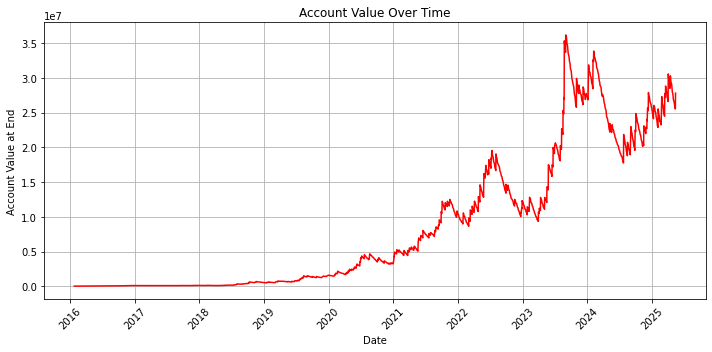

In [88]:
# Ensure date column is datetime (optional but helpful)
audit['date'] = pd.to_datetime(audit['date'])

# Convert to NumPy arrays
dates = audit['date'].to_numpy()
account_values = audit['account_value_end'].to_numpy()

# Plot
plt.figure(figsize=(10, 5))
plt.plot(dates, account_values, color='red', linestyle='-')
plt.xlabel('Date')
plt.ylabel('Account Value at End')
plt.title('Account Value Over Time')
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


## Performance Metrics

In [93]:
#New function to fix drawdowns
def analyze_drawdowns(audit):
    i = 0  # Current drawdown length
    max_consecutive_losses = 0
    max_drawdown = 0
    drawdown_durations = []  # Store lengths of each drawdown

    for j in range(1, len(audit)):
        if audit.loc[j, "percentage_return"] < 0:
            if i == 0:
                # Start of new drawdown
                init_cash = audit.loc[j, "account_value_end"] - audit.loc[j, "dollar_profit"]
            i += 1
        elif i > 0:
            # End of drawdown
            end_cash = audit.loc[j - 1, "account_value_end"]
            max_consecutive_losses = max(max_consecutive_losses, i)

            drawdown = (end_cash - init_cash) / init_cash
            max_drawdown = min(drawdown, max_drawdown)

            drawdown_durations.append(i)
            i = 0  # Reset counter

    # Handle case if the drawdown continues until the end of the DataFrame
    if i > 0:
        end_cash = audit.loc[len(audit) - 1, "account_value_end"]
        max_consecutive_losses = max(max_consecutive_losses, i)
        drawdown = (end_cash - init_cash) / init_cash
        max_drawdown = min(drawdown, max_drawdown)
        drawdown_durations.append(i)

    average_drawdown_duration = sum(drawdown_durations) / len(drawdown_durations) if drawdown_durations else 0

    return max_consecutive_losses, max_drawdown, average_drawdown_duration


def evaluate_audit(audit, start_date=None, end_date=None):
    df = pd.DataFrame(audit)
    df['date'] = pd.to_datetime(df['date'])
    df['entry_time'] = pd.to_datetime(df['entry_time'])
    df['exit_time'] = pd.to_datetime(df['exit_time'])

    # Apply date filtering if provided
    if start_date:
        start_date = pd.to_datetime(start_date)
        df = df[df['date'] >= start_date]
    if end_date:
        end_date = pd.to_datetime(end_date)
        df = df[df['date'] <= end_date]

    df = df.sort_values('date').reset_index(drop=True)

    # Compute daily returns
    df['daily_return'] = df['dollar_profit'] / df['account_value_end'].shift(1)
    df['daily_return'] = df['daily_return'].fillna(0)

    # Cumulative return
    cumulative_return = (1 + df['daily_return']).prod() - 1

    # Annualized return and volatility
    annualized_return = (1 + cumulative_return)**(252 / len(df)) - 1
    volatility = df['daily_return'].std() * np.sqrt(252)

    # Sharpe Ratio (risk-free rate = 0)
    sharpe_ratio = df['daily_return'].mean() / df['daily_return'].std() * np.sqrt(252)

    # Sortino Ratio
    downside_std = df[df['daily_return'] < 0]['daily_return'].std()
    sortino_ratio = (
        df['daily_return'].mean() / downside_std * np.sqrt(252)
        if downside_std != 0 else np.nan
    )

    # Count wins and losses
    wins = df['dollar_profit'] > 0
    losses = df['dollar_profit'] < 0

    # Consecutive gains and losses
    df['win_group'] = (~wins).cumsum()
    max_consec_gains = wins.groupby(df['win_group']).sum().max() if not wins.empty else 0

    df['loss_group'] = (~losses).cumsum()
    max_consec_losses = losses.groupby(df['loss_group']).sum().max() if not losses.empty else 0

    # Win/loss stats
    total_win = df.loc[wins, 'dollar_profit'].sum()
    total_loss = abs(df.loc[losses, 'dollar_profit'].sum())
    percent_wins = wins.sum() / (wins.sum() + losses.sum()) if (wins.sum() + losses.sum()) > 0 else np.nan
    avg_win = df.loc[wins, 'daily_return'].mean() * 100
    avg_loss = df.loc[losses, 'daily_return'].mean() * 100

    # Profit factor
    profit_factor = total_win / total_loss if total_loss != 0 else np.nan

    # Max Drawdown and Drawdown Duration
    max_consecutive_losses, max_drawdown, avg_drawdown_duration=analyze_drawdowns(audit)

    # Calmar Ratio
    calmar_ratio = annualized_return / abs(max_drawdown) if max_drawdown != 0 else np.nan

    # Average Trades per year
    df['year'] = df['date'].dt.year
    trades_per_year = int(df.groupby('year').size().mean())

    # Yearly and Quarterly returns
    yearly_returns = df.groupby('year')['daily_return'].apply(lambda x: (1 + x).prod() - 1)
    df['quarter'] = df['date'].dt.to_period('Q')
    quarterly_returns = df.groupby('quarter')['daily_return'].apply(lambda x: (1 + x).prod() - 1)

    # Monthly Returns
    df['month'] = df['date'].dt.to_period('M')
    monthly_returns = df.groupby('month')['daily_return'].apply(lambda x: (1 + x).prod() - 1)
    avg_monthly_return = monthly_returns.mean() * 100
    median_monthly_return = monthly_returns.median() * 100

    # Trade Duration: Median and Average (in hours)
    df['trade_duration'] = (df['exit_time'] - df['entry_time']).dt.total_seconds() / 3600
    avg_trade_duration = df['trade_duration'].mean()
    median_trade_duration = df['trade_duration'].median()

    # Results
    return {
      'Backtest Start Date': start_date.strftime('%Y-%m-%d') if start_date else str(df['date'].min().date()),
      'Backtest End Date': end_date.strftime('%Y-%m-%d') if end_date else str(df['date'].max().date()),
      'Initial Balance': audit['account_value_end'].iloc[0] - audit['dollar_profit'].iloc[0],
      'Final Balance': audit['account_value_end'].iloc[-1],
      'Sharpe Ratio': round(sharpe_ratio, 2),
      'Sortino Ratio': round(sortino_ratio, 2),
      'Calmar Ratio': round(calmar_ratio, 2),
      'Cumulative Return': f"{round(cumulative_return * 100, 2)}%",
      'Annualized Return': f"{round(annualized_return * 100, 2)}%",
      'Volatility (Annualized)': f"{round(volatility * 100, 2)}%",
      'Max Drawdown': f"{round(max_drawdown * 100, 2)}%",
      'Average Drawdown Duration (days)': round(avg_drawdown_duration, 2),
      'Average Trade Duration (hrs)': round(avg_trade_duration, 2),
      'Median Trade Duration (hrs)': round(median_trade_duration, 2),
      'Max Consecutive Gains': int(max_consec_gains),
      'Max Consecutive Losses': int(max_consec_losses),
      '% Winning Trades': f"{round(percent_wins * 100, 2)}%",
      'Average Win (%)': f"{round(avg_win, 2)}%",
      'Average Loss (%)': f"{round(avg_loss, 2)}%",
      'Profit Factor (Win/Loss Ratio)': round(profit_factor, 2),
      'Average trades per Year': round(trades_per_year, 2),
      'Yearly Returns': {int(year): f"{round(ret * 100, 2)}%" for year, ret in yearly_returns.items()},
      'Quarterly Returns': {str(q): f"{round(ret * 100, 2)}%" for q, ret in quarterly_returns.items()},
      'Monthly Returns': {str(month): f"{round(ret * 100, 2)}%" for month, ret in monthly_returns.items()},
      'Average Monthly Return': f"{round(avg_monthly_return, 2)}%",
      'Median Monthly Return': f"{round(median_monthly_return, 2)}%",
  }

# Print example
start_date = '2024-01-01'
results = evaluate_audit(audit, None, None)
for k, v in results.items():
    print(f"{k}: {v}")


Backtest Start Date: 2016-01-26
Backtest End Date: 2025-05-13
Initial Balance: 25000.0
Final Balance: 27803591.11
Sharpe Ratio: 1.6
Sortino Ratio: 35.34
Calmar Ratio: 4.16
Cumulative Return: 112237.41%
Annualized Return: 131.47%
Volatility (Annualized): 64.23%
Max Drawdown: -31.62%
Average Drawdown Duration (days): 8.73
Average Trade Duration (hrs): 1.07
Median Trade Duration (hrs): 0.08
Max Consecutive Gains: 3
Max Consecutive Losses: 38
% Winning Trades: 11.33%
Average Win (%): 10.11%
Average Loss (%): -0.83%
Profit Factor (Win/Loss Ratio): 1.19
Average trades per Year: 210
Yearly Returns: {2016: '328.34%', 2017: '17.26%', 2018: '332.71%', 2019: '197.43%', 2020: '106.24%', 2021: '215.85%', 2022: '17.21%', 2023: '124.32%', 2024: '-7.44%', 2025: '9.62%'}
Quarterly Returns: {'2016Q1': '54.19%', '2016Q2': '37.1%', '2016Q3': '26.32%', '2016Q4': '60.41%', '2017Q1': '-1.36%', '2017Q2': '-12.39%', '2017Q3': '17.33%', '2017Q4': '15.65%', '2018Q1': '-17.28%', '2018Q2': '64.44%', '2018Q3': '135

## PARAMETER TUNNING

In [94]:
from itertools import product
# Ordered parameter names as expected by the function
ordered_keys = [
    'window_size',
    'leverage_factor',
    'profit_target_multiplier',
    'stop_loss',
    'atr_percent',
    'threshold',
    'entry'
]


# WINDOW_SIZE: [5,10,15 min]
# LEVERAGE_FACTOR: [1X, 3x, 4x, 12x]
# PROFIT TARGET_MULTIPLIER: [None, 5R, 10R, 15R]
# STOP_LOSS_STRATEGY: [basic, atr, basic+atr]
# ATR_PERCENT: [2%, 5%, 10%]
# THRESHOLD: [0, 0.02%, 0.05%]
# STOP_ENTRY: [basic,advanced] (standard ORB vs enter at high of previous day)
# Parameter grid
param_grid = {
    'window_size': [5, 10, 15],
    #'leverage_factor': [1, 3, 4, 12], #RJ_CODE modifying the parameters that we want to test - entry advanced is not part of ORB testing
    'leverage_factor': [12],
    #'profit_target_multiplier': [None, 5, 10, 15],
    'profit_target_multiplier': [None],
    #'stop_loss_strategy': ["basic", "atr", "basic+atr"],
    'stop_loss_strategy': ["basic", "atr"],
    'atr_percent': [2, 5, 10],
    'threshold': [0, 0.02],  # 0.02%
    # 'entry': ['basic', 'advanced']
    'entry': ['basic']
}

# Generate all parameter combinations
all_combinations = list(product(*param_grid.values()))

# Store all results
results = []
failed = []

for i, combination in enumerate(all_combinations):
    try:
        # Call the function with unpacked arguments
        audit = generalized_orb(final_df_read, *combination)
        score = evaluate_audit(audit, None, None)

        # Build result dictionary
        result_entry = dict(zip(ordered_keys, combination))
        print(result_entry)

        if isinstance(score, dict):
            result_entry.update(score)
        else:
            raise ValueError("score is not a dictionary")

        results.append(result_entry)

    except Exception as e:
        print(f"[{i+1}/{len(all_combinations)}] Error with params {combination}: {e}")
        failed.append((combination, str(e)))


# Save all results to DataFrame
results_df = pd.DataFrame(results)
results_df.to_csv("orb_results_final.csv", index=False)



{'window_size': 5, 'leverage_factor': 12, 'profit_target_multiplier': None, 'stop_loss': 'basic', 'atr_percent': 2, 'threshold': 0, 'entry': 'basic'}
{'window_size': 5, 'leverage_factor': 12, 'profit_target_multiplier': None, 'stop_loss': 'basic', 'atr_percent': 2, 'threshold': 0.02, 'entry': 'basic'}
{'window_size': 5, 'leverage_factor': 12, 'profit_target_multiplier': None, 'stop_loss': 'basic', 'atr_percent': 5, 'threshold': 0, 'entry': 'basic'}
{'window_size': 5, 'leverage_factor': 12, 'profit_target_multiplier': None, 'stop_loss': 'basic', 'atr_percent': 5, 'threshold': 0.02, 'entry': 'basic'}
{'window_size': 5, 'leverage_factor': 12, 'profit_target_multiplier': None, 'stop_loss': 'basic', 'atr_percent': 10, 'threshold': 0, 'entry': 'basic'}
{'window_size': 5, 'leverage_factor': 12, 'profit_target_multiplier': None, 'stop_loss': 'basic', 'atr_percent': 10, 'threshold': 0.02, 'entry': 'basic'}
{'window_size': 5, 'leverage_factor': 12, 'profit_target_multiplier': None, 'stop_loss': 

In [95]:
a= results_df.sort_values(by="Sortino Ratio", ascending=False)
for index, row in a.iterrows():
    print(row)

window_size                                                                         5
leverage_factor                                                                    12
profit_target_multiplier                                                         None
stop_loss                                                                         atr
atr_percent                                                                        10
threshold                                                                        0.02
entry                                                                           basic
Backtest Start Date                                                        2016-01-26
Backtest End Date                                                          2025-05-13
Initial Balance                                                               25000.0
Final Balance                                                              2726201.12
Sharpe Ratio                                          